# Structured Output

Structured output refers to the ability to get information from the Gemini model in a well-organized, predictable format, usually as JSON, CSV, or a table, instead of just free form text (unstructured output like paragraphs).

Example:

1. Unsturctured: "Anshu has 7 years of experience in Artificial Intelligence. He worked at SpaceX and specializes in Python, SQL, and C/C++.

2. Structured:

{
  
  "name": "Anshu",

  "experience: "7 years",

  "previous_company: "SpaceX",

  "skills": ["Python", "SQL", "C/C++"]
    
}

Benefits:

1. Store in databases.
2. Feed into automated pipelines.
3. Analyze with BI tools or ML models.
4. Use in system to system communication.



Gemini can generate either JSON or enum values as structured output.

Let's start with JSON first:

JSON: It stands for JavaScript Object Notation.

It is a lightweight, human readable format used to store and exchange structured data between systems (especially between servers and web applications).

JSON is made of key value pairs.

{
  
  "key1": "value1",

  "key2": 123,

  "key3": true,

  "key4": [1, 2, 3],

  "key5": {"nestedkey": "nestedvalue"}

}

Generating JSON:

1. We need to first configure the schema of the model.

2. "Configure a schema on the model" means you tell the model in advance exactly what kind of structured response (e.g., JSON format) you want.

3. You define this using a predefined schema which guides the model to fill out the correct fields in the response.

In [34]:
# Step 1: Install the Google Gemini AI SDK
!pip install -q google-generativeai

In [35]:
# API KEY
import os
os.environ["GOOGLE_API_KEY"] = "ENTER_API_KEY"

In [36]:
from google import genai
from google.genai import types
from pydantic import BaseModel # Importing Pydantic BaseModel Class
from typing import List
import json
from PIL import Image
import pandas as pd
import enum

In [37]:
# Initialize a Gemini client instance for interacting with the API
client = genai.Client()

In [38]:
# defining schema
class Web_Series(BaseModel):
  web_series_name: str
  year_of_starting: int
  creator_name: str
  rating: int
  review: list[str]

In [39]:
prompt_1 = "List some popular most watached web series, and for each, include its year of starting, the creator's name,rating out of 5 and webseries review"

response_1 = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt_1,
    config={
        "response_mime_type": "application/json",
        "response_schema": list[Web_Series]
    }
)

print(response_1)

sdk_http_response=HttpResponse(
  headers=<dict len=10>
) candidates=[Candidate(
  content=Content(
    parts=[
      Part(
        text='[{"web_series_name":"Stranger Things","year_of_starting":2016,"creator_name":"Duffer Brothers","rating":5,"review":["Compelling storyline","Excellent character development","Nostalgic 80s vibe","Suspenseful and thrilling"]},{"web_series_name":"The Crown","year_of_starting":2016,"creator_name":"Peter Morgan","rating":4,"review":["Historical accuracy","Stellar performances","Beautiful cinematography","Engaging portrayal of the royal family"]},{"web_series_name":"Money Heist","year_of_starting":2017,"creator_name":"Álex Pina","rating":5,"review":["High-octane plot","Brilliant twists and turns","Charismatic characters","Intense and addictive"]},{"web_series_name":"The Mandalorian","year_of_starting":2019,"creator_name":"Jon Favreau","rating":4,"review":["Stunning visuals","Classic Star Wars feel","Engaging character journey","Action-packed and emotional"

In [40]:
# Convert parsed Pydantic models to dicts, then pretty-print
print(json.dumps([item.dict() for item in response_1.parsed], indent=2))

[
  {
    "web_series_name": "Stranger Things",
    "year_of_starting": 2016,
    "creator_name": "Duffer Brothers",
    "rating": 5,
    "review": [
      "Compelling storyline",
      "Excellent character development",
      "Nostalgic 80s vibe",
      "Suspenseful and thrilling"
    ]
  },
  {
    "web_series_name": "The Crown",
    "year_of_starting": 2016,
    "creator_name": "Peter Morgan",
    "rating": 4,
    "review": [
      "Historical accuracy",
      "Stellar performances",
      "Beautiful cinematography",
      "Engaging portrayal of the royal family"
    ]
  },
  {
    "web_series_name": "Money Heist",
    "year_of_starting": 2017,
    "creator_name": "\u00c1lex Pina",
    "rating": 5,
    "review": [
      "High-octane plot",
      "Brilliant twists and turns",
      "Charismatic characters",
      "Intense and addictive"
    ]
  },
  {
    "web_series_name": "The Mandalorian",
    "year_of_starting": 2019,
    "creator_name": "Jon Favreau",
    "rating": 4,
    "revie

/tmp/ipython-input-2173909760.py:2: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  print(json.dumps([item.dict() for item in response_1.parsed], indent=2))


In [41]:
"""
1. converting data in dataframe
2. firstly, we need to parse above response into a list of dict and then convert it into list and at last convert it into dataframe
  a) response.parse
  b) convert them into dict
  c) list -------> dataframe
"""

# converting response data into dataframe
dataframe_1 = pd.DataFrame([i.model_dump() for i in response_1.parsed])
dataframe_1

,web_series_name,year_of_starting,creator_name,rating,review
0,Stranger Things,2016,Duffer Brothers,5,"[Compelling storyline, Excellent character dev..."
1,The Crown,2016,Peter Morgan,4,"[Historical accuracy, Stellar performances, Be..."
2,Money Heist,2017,Álex Pina,5,"[High-octane plot, Brilliant twists and turns,..."
3,The Mandalorian,2019,Jon Favreau,4,"[Stunning visuals, Classic Star Wars feel, Eng..."
4,Squid Game,2021,Hwang Dong-hyuk,5,"[Unique and thrilling concept, Dark and though..."


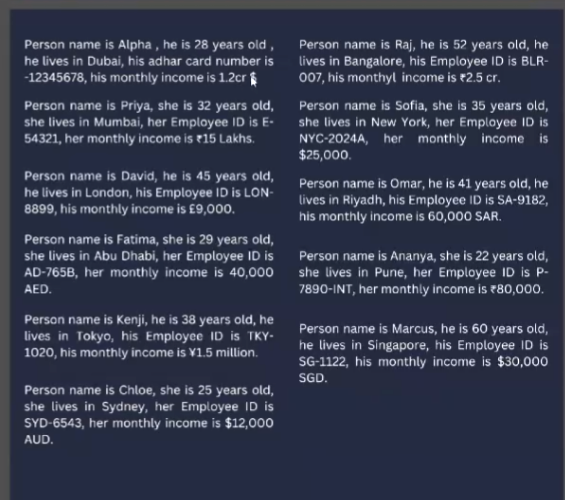

In [42]:
# displaying image
image_1 = Image.open("/content/i1.png")
image_1

In [43]:
# defining schema
class Employee(BaseModel):
  name: str
  age: str
  gender: str
  address: str
  emp_id: str
  monthly_income: str
  income_currency: str

In [44]:
prompt_2 = "From the given text in image, extract all the information that is available as the given given json structure"

response_2 = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[image_1, prompt_2],
    config={
        "response_mime_type": "application/json",
        "response_schema": list[Employee]
    }
)

print(response_2)

sdk_http_response=HttpResponse(
  headers=<dict len=10>
) candidates=[Candidate(
  content=Content(
    parts=[
      Part(
        text="""[
  {
    "name": "Alpha",
    "age": "28",
    "gender": "Male",
    "address": "Dubai",
    "emp_id": "-12345678",
    "monthly_income": "1.2 cr",
    "income_currency": "INR"
  },
  {
    "name": "Priya",
    "age": "32",
    "gender": "Female",
    "address": "Mumbai",
    "emp_id": "E-54321",
    "monthly_income": "15 Lakhs",
    "income_currency": "INR"
  },
  {
    "name": "David",
    "age": "45",
    "gender": "Male",
    "address": "London",
    "emp_id": "LON-8899",
    "monthly_income": "9,000",
    "income_currency": "GBP"
  },
  {
    "name": "Fatima",
    "age": "29",
    "gender": "Female",
    "address": "Abu Dhabi",
    "emp_id": "AD-765B",
    "monthly_income": "40,000",
    "income_currency": "AED"
  },
  {
    "name": "Kenji",
    "age": "38",
    "gender": "Male",
    "address": "Tokyo",
    "emp_id": "TKY-1020",
    "monthly_

In [45]:
# Convert parsed Pydantic models to dicts, then pretty-print
print(json.dumps([item.model_dump() for item in response_2.parsed], indent=2))

[
  {
    "name": "Alpha",
    "age": "28",
    "gender": "Male",
    "address": "Dubai",
    "emp_id": "-12345678",
    "monthly_income": "1.2 cr",
    "income_currency": "INR"
  },
  {
    "name": "Priya",
    "age": "32",
    "gender": "Female",
    "address": "Mumbai",
    "emp_id": "E-54321",
    "monthly_income": "15 Lakhs",
    "income_currency": "INR"
  },
  {
    "name": "David",
    "age": "45",
    "gender": "Male",
    "address": "London",
    "emp_id": "LON-8899",
    "monthly_income": "9,000",
    "income_currency": "GBP"
  },
  {
    "name": "Fatima",
    "age": "29",
    "gender": "Female",
    "address": "Abu Dhabi",
    "emp_id": "AD-765B",
    "monthly_income": "40,000",
    "income_currency": "AED"
  },
  {
    "name": "Kenji",
    "age": "38",
    "gender": "Male",
    "address": "Tokyo",
    "emp_id": "TKY-1020",
    "monthly_income": "1.5 million",
    "income_currency": "JPY"
  },
  {
    "name": "Chloe",
    "age": "25",
    "gender": "Female",
    "address": "

In [46]:
# converting response data into dataframe
dataframe_2 = pd.DataFrame([i.model_dump() for i in response_2.parsed])
dataframe_2

,name,age,gender,address,emp_id,monthly_income,income_currency
0,Alpha,28,Male,Dubai,-12345678,1.2 cr,INR
1,Priya,32,Female,Mumbai,E-54321,15 Lakhs,INR
2,David,45,Male,London,LON-8899,"9,000",GBP
3,Fatima,29,Female,Abu Dhabi,AD-765B,"40,000",AED
4,Kenji,38,Male,Tokyo,TKY-1020,1.5 million,JPY
5,Chloe,25,Female,Sydney,SYD-6543,"12,000",AUD
6,Raj,52,Male,Bangalore,BLR-007,2.5 cr,INR
7,Sofia,35,Female,New York,NYC-2024A,"25,000",USD
8,Omar,41,Male,Riyadh,SA-9182,"60,000",SAR
9,Ananya,22,Female,Pune,P-7890-INT,"80,000",INR


In [47]:
# by giving instruction inside prompt

# this way is less reliable ,

# extract data from an image
# governmet data from that extract content

image_2 = Image.open("/content/i1.png")

response_3 = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[image_2, '''from the given image that contains text , extract all the information that is available as per the given structure
                      'name: str
                      'age: int'
                      'gender: str'
                      'address: str'
                      'aadhaar: str'
                      'monthly_income:  int'
                      'income_currency: str'''
    ],
)

print(response_3.text)

```json
[
  {
    "name": "Alpha",
    "age": 28,
    "gender": "Male",
    "address": "Dubai",
    "aadhaar": "-12345678",
    "monthly_income": 12000000,
    "income_currency": "INR"
  },
  {
    "name": "Priya",
    "age": 32,
    "gender": "Female",
    "address": "Mumbai",
    "aadhaar": "E-54321",
    "monthly_income": 1500000,
    "income_currency": "INR"
  },
  {
    "name": "David",
    "age": 45,
    "gender": "Male",
    "address": "London",
    "aadhaar": "LON-8899",
    "monthly_income": 9000,
    "income_currency": "GBP"
  },
  {
    "name": "Fatima",
    "age": 29,
    "gender": "Female",
    "address": "Abu Dhabi",
    "aadhaar": "AD-765B",
    "monthly_income": 40000,
    "income_currency": "AED"
  },
  {
    "name": "Kenji",
    "age": 38,
    "gender": "Male",
    "address": "Tokyo",
    "aadhaar": "TKY-1020",
    "monthly_income": 1500000,
    "income_currency": "JPY"
  },
  {
    "name": "Chloe",
    "age": 25,
    "gender": "Female",
    "address": "Sydney",
    "

Generating Enum:

Enum stands for 'Enumertion'. It is a data type that defines a set of named values, called members or constants, that a variable can take.

Think of it like a drop down menu in a form, where only a few specific choices are allowed.

In short, it is a structured output in which, we define ourselves what we want in the output.

Example:

pdf:-

    name:

    dignosis:

    medicines:

    finale_remark: admit, admitted, stay in hospital

The meaning of all these final remark is the same, but if I generate them in the form of a structured output, they will appear as different entities — even though they represent the same thing. This reduces the clarity of the data.

To handle such cases, we use enums. Enums allow us to define a fixed set of rules or possible values.

For example, if we give an LLM a 700-page PDF and ask, “What is the final remark?”, the model might generate the final remark as defined in our earlier example. However, we don’t want it to display three different variations of the same value — we want it as a single, unified output.

That’s why we use enums — to ensure that the model outputs one standardized value instead of multiple similar ones.

1. admit: admitted
2. admitted: admitted
3. stay in hospital: admitted

In [49]:
"""
problem: country ---> continent
"""

response_4 = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Where is India"
)

print(response_4.text)

India is a large country located in **South Asia**.

Here's a breakdown of its geographical position:

*   **Continent:** Asia
*   **Subregion:** South Asia
*   **Surrounding Water Bodies:**
    *   **Indian Ocean** to the south.
    *   **Arabian Sea** to the southwest.
    *   **Bay of Bengal** to the southeast.
*   **Land Borders (Clockwise from West):**
    *   **Pakistan** to the west.
    *   **China**, **Nepal**, and **Bhutan** to the north.
    *   **Bangladesh** and **Myanmar** (Burma) to the east.
*   **Maritime Neighbors:**
    *   **Sri Lanka** across the narrow Palk Strait to the southeast.
    *   **Maldives** further south in the Indian Ocean.

Essentially, India forms a large **peninsula** that extends southwards into the Indian Ocean, with the mighty Himalayan mountain range defining its northern border.


As we saw in the above response_4, the output shows “South Asia.” But we don’t want the output to be in forms like East, South, North, or West Asia — we simply want the output to be “Asia.”

That’s why we use enums — to standardize and restrict outputs to specific predefined values.

In [50]:
# defining schema
class continent(enum.Enum):
  NORTH_ASIA = "ASIA"
  SOUTH_ASIA = "ASIA"
  EAST_ASIA = "ASIA"
  WEST_ASIA = "ASIA"
  CENTRAL_ASIA = "ASIA"
  OTHER = "NOT ASIA"

In [51]:
response_5 = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Where is India",
    config={
        "response_mime_type":"text/x.enum",
        "response_schema":continent
    }
)

print(response_5.text)

ASIA


In our schema, we’ve placed “NOT ASIA” under the “OTHER” category so that if a user enters a country from any continent other than Asia, or any unrelated text, the model will output “NOT ASIA” according to the schema.

And if the user enters a country that belongs to the Asian continent, then the model will output “ASIA” as per the schema.